# Data Preparation and Feature Engineering

**Procurement contract risk classification · World Bank contract awards in IPF, FY2020 onward**

This notebook is the narrative layer. All logic lives in `src/procurement_risk/` so the same
functions can be imported by the downstream stages — rule engine, risk model, anomaly check,
cohort assignment — and unit-tested (`pytest tests/`, 38 tests).

### What this stage produces

1. Parsed and cleaned dates, amounts, country codes, procurement method and supplier fields.
2. Derived features: amount against two benchmarks, supplier domesticity, first-in-project,
   supplier prior-contract count, days into the fiscal year, method competitiveness.
3. A documented register of missing, inconsistent and out-of-range values — *with the reasoning*.
4. A summary of amount distribution, category mix, regional coverage and data-quality patterns.
5. `validate_and_enrich(record)` — returns a **data quality flag rather than silently filling a value**.

### The principle everything else follows from

> Each record is scored **as if at the moment the contract was submitted**, using only
> information available at that point.

Two things follow, and they are the spine of this notebook:

- **Unknown is not zero.** A missing supplier history and a supplier with no history are different
  facts. Collapsing them into `0` is the single most consequential mistake available here, and it
  would be invisible downstream. Every feature that can be unknowable is tri-state.
- **Population statistics must declare their time window.** Benchmarks and history counts leak
  differently, so they are fitted differently. Section 4 explains why.

### Scope decisions

| Decision | Choice | Reasoning |
|---|---|---|
| Population | All 288,237 rows; `review_type` kept as a feature | Reviewer effort concentrates on prior review, but a prior-review-only population leaves ~20k rows over eight fiscal years and ~200 in the most recent — too thin for a time-based split. A prior-review slice is reported separately instead. |
| Sampling | **None** | 288k rows is ~200 MB, well within memory, so sampling buys nothing and would risk interacting with the time-based split. |
| Currency | Raw USD, no inflation adjustment | The extract is already USD-converted at an undisclosed rate/date. Deflating would layer one unverifiable assumption on another. Benchmark drift is measured instead (Section 6). |
| Grain | One row per **supplier-award**; statistics at **contract** grain | 3.1% of contracts are joint ventures split across rows that each repeat the full amount. |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

from procurement_risk import config, summary as S
from procurement_risk.loading import load_raw
from procurement_risk.cleaning import clean_frame, contract_grain
from procurement_risk.features import build_reference_stats, engineer_features, FEATURE_COLUMNS
from procurement_risk.pipeline import validate_and_enrich

print("pipeline version:", config.PIPELINE_VERSION, "| extract as-of:", config.DATA_AS_OF_DATE)

pipeline version: v1.0 | extract as-of: 2026-08-22


## 1. Load

The loader renames columns to snake_case and coerces nothing else. Dates are deliberately **not**
parsed at load time: pandas would coerce an unreadable date to `NaT`, which is indistinguishable
from a genuinely absent one. Both need to reach the quality register as distinct findings.

In [2]:
raw = load_raw()
print(f"{len(raw):,} rows x {raw.shape[1]} columns")
raw.head(3).T

288,237 rows x 21 columns


,0,1,2
as_of_date,08/22/2026,08/22/2026,08/22/2026
fiscal_year_published,2027,2027,2027
region,Western and Central Africa,Eastern and Southern Africa,East Asia and Pacific
borrower_country,"Congo, Republic of",Kenya,Viet Nam
borrower_country_code,CG,KE,VN
project_id,P177468,P170941,P164938
project_name,Accelerating Governance Institutional Reforms ...,Kenya Digital Economy Acceleration Project,Vietnam Scaling Up Energy Efficiency Project
global_practice_raw,Public Admin;Education;Health,Info & Communication,Financial Sector;Energy & Extractives;Industry...
procurement_category,Goods,Goods,Consultant Services
procurement_method_raw,Request for Quotations,Request for Bids,Consultant Qualification Selection


## 2. Cleaning

Cleaning changes *representation* (casing, whitespace, legal suffixes, multi-valued fields).
It never invents a value.

In [3]:
clean = clean_frame(raw)
print(f"{len(clean):,} rows, {clean.shape[1]} columns after cleaning")
clean[["supplier_name_raw","supplier_name","supplier_key","global_practice_raw","global_practice",
       "procurement_method_raw","method_class","signing_date","fiscal_year",
       "days_into_fiscal_year","supplier_is_domestic","consortium_size"]].head(5)

288,237 rows, 37 columns after cleaning


,supplier_name_raw,supplier_name,supplier_key,global_practice_raw,global_practice,procurement_method_raw,method_class,signing_date,fiscal_year,days_into_fiscal_year,supplier_is_domestic,consortium_size
0,DD SERVICES,DD SERVICES,DD SERVICES,Public Admin;Education;Health,Public Admin,Request for Quotations,COMPETITIVE,2026-08-17,2027,47,True,1
1,TRITEL TECHNOLOGIES LTD I,TRITEL TECHNOLOGIES LTD I,TRITEL TECHNOLOGIES LTD I,Info & Communication,Info & Communication,Request for Bids,COMPETITIVE,2026-08-17,2027,47,True,1
2,ENVIRONMENT AND ECOLOGY INSTITUTE (EEI),ENVIRONMENT AND ECOLOGY INSTITUTE EEI,ENVIRONMENT AND ECOLOGY INSTITUTE EEI,Financial Sector;Energy & Extractives;Industry...,Financial Sector,Consultant Qualification Selection,COMPETITIVE,2026-08-14,2027,44,True,1
3,"OTT CONSTRUCTORS COMPANY, LTD.",OTT CONSTRUCTORS COMPANY,OTT CONSTRUCTORS COMPANY,Transportation,Transportation,Request for Bids,COMPETITIVE,2026-08-14,2027,44,True,1
4,LONGJIAN ROAD & BRIDGE CO.LTD. (LRBC),LONGJIAN ROAD & BRIDGE CO LTD LRBC,LONGJIAN ROAD & BRIDGE CO LTD LRBC,Transportation,Transportation,Request for Bids,COMPETITIVE,2026-08-14,2027,44,False,1


### 2.1 The procurement-method taxonomy

An **exhaustive lookup**, never a keyword heuristic. "Method cannot be mapped to a known category"
is a `NOT_ELIGIBLE` rule in the rule engine — a heuristic that always returns *something* would
quietly disable that control. Two entries are genuine judgment calls and are labelled as such.

A concrete trap found here: the source spells CQS as `Consultant Qualification··Selection` with a
**double space**. Any whitespace-collapsing cleaner breaks an exact-string lookup and wrongly fails
15,956 records (5.5%) as "unmapped". Both sides of the lookup are now whitespace- and case-folded,
and there is a regression test for it.

In [4]:
tax = S.method_taxonomy_table()
counts = clean["procurement_method_raw"].value_counts()
tax["rows"] = tax["method"].map(counts).fillna(0).astype(int)
tax.style.set_properties(subset=["rationale"], **{"white-space": "normal", "text-align": "left"})

,method,class,rationale,rows
0,Consultant Qualification Selection,COMPETITIVE,"CQS: shortlist compared on qualifications. Weakest competitive method (no price competition, small shortlist) but still comparative, so classed competitive with the caveat noted.",15956
1,E-Auctions,COMPETITIVE,Electronic reverse auction; competition on price is the mechanism itself.,76
2,Fixed Budget Selection,COMPETITIVE,FBS: firms compete on quality within a disclosed fixed budget.,228
3,Individual Consultant Selection,COMPETITIVE,"ICS: at least three CVs compared. Classed competitive, but note that 22% of the dataset is ICS and its supplier field is a placeholder, not a firm.",63603
4,Least Cost Selection,COMPETITIVE,LCS: shortlisted firms meeting a quality floor compete on price.,1554
5,Quality And Cost-Based Selection,COMPETITIVE,QCBS: shortlisted firms compete on combined quality and cost score.,10678
6,Quality Based Selection,COMPETITIVE,"QBS: shortlist competes on quality; cost negotiated after ranking, still multi-firm.",555
7,Request for Bids,COMPETITIVE,Open advertised bidding; the Bank's default competitive method for Goods/Works.,55254
8,Request for Proposals,COMPETITIVE,Competitive proposals evaluated on technical merit and price.,459
9,Request for Quotations,COMPETITIVE,Shopping against multiple quotations; competitive though lightweight and low-value.,104261


In [5]:
assert clean["method_class"].isna().sum() == 0, "every observed method must map"
print("competitive rows:      {:>7,}".format(int((clean.method_class=='COMPETITIVE').sum())))
print("non-competitive rows:  {:>7,}".format(int((clean.method_class=='NON_COMPETITIVE').sum())))
print("unmapped:              {:>7,}".format(int(clean.method_class.isna().sum())))

competitive rows:      252,624
non-competitive rows:   35,613
unmapped:                    0


### 2.2 Supplier identity — the biggest single finding

`Supplier` is **not** an entity column for a fifth of this dataset.

`INDIVIDUAL CONSULTANT` appears **63,603 times (22.1%)** across **53,905 distinct Supplier IDs**,
and only ever on `Individual Consultant Selection` rows. It is a category label standing in for a
natural person whose name is withheld.

Why this matters more than it first appears: the feature set needs a count of prior contracts from
the same supplier. Computed naively, 22% of the dataset would share the contract history of the
single most prolific supplier in the portfolio — and would therefore look maximally *familiar* and
*low risk*. That is precisely backwards: these are the records we know least about.

**Decision:** these records are marked supplier-unidentifiable, and supplier-history features return
`None` with a `SUPPLIER_UNIDENTIFIABLE` flag. Not zero — zero would mean "brand new supplier", which
is also a claim we cannot support.

`Supplier ID` is not usable as the entity key either: 183,980 IDs for 121,914 names, and 53,905 of
those IDs belong to the placeholder alone. It behaves like a per-award reference, not a durable
vendor identifier. We key on the normalised name and say so, rather than trusting the field that
merely looks like a primary key.

In [6]:
ph = clean["supplier_name"] == "INDIVIDUAL CONSULTANT"
print(f"placeholder rows            : {ph.sum():>7,} ({ph.mean()*100:.1f}%)")
print(f"distinct Supplier IDs behind: {raw.loc[ph.values,'supplier_id'].nunique():>7,}")
print(f"methods it appears under    : {clean.loc[ph,'procurement_method_raw'].unique().tolist()}")
print(f"\nsupplier_key null (placeholder + genuinely missing): {clean.supplier_key.isna().sum():,}")
print(f"resolved distinct suppliers : {clean.supplier_key.nunique():,}")

placeholder rows            :  63,603 (22.1%)
distinct Supplier IDs behind:  53,905
methods it appears under    : ['Individual Consultant Selection']

supplier_key null (placeholder + genuinely missing): 63,609
resolved distinct suppliers : 117,950


### 2.3 Joint ventures duplicate the contract amount

8,584 contract numbers (3.1%) carry more than one supplier row, and most repeat the **full**
contract amount on every row. Any statistic computed over raw rows double-counts money: a
three-way JV would push its amount into the median three times.

**Decision:** reporting stays at row grain (one row per supplier-award, which is what the extract
is), but every *population statistic* — medians, history counts — is computed at contract grain.

In [7]:
impact = S.consortium_impact(clean, contract_grain(clean))
for k, v in impact.items():
    print(f"{k:<35} {v:>15,}" if isinstance(v,(int,np.integer)) else f"{k:<35} {v:>15}")
print(f"\ninflation if computed on raw rows: "
      f"{impact['row_grain_total_usd_bn']/impact['contract_grain_total_usd_bn']-1:.1%}")

supplier_rows                               288,237
distinct_contracts                          276,417
rows_in_multi_supplier_contracts             20,404
multi_supplier_contracts                      8,584
largest_consortium                               42
row_grain_total_usd_bn                        130.1
contract_grain_total_usd_bn                   116.6

inflation if computed on raw rows: 11.6%


### 2.4 Missing borrower country codes are not random

3.35% of rows have no borrower ISO code. Two distinct causes hide behind that one number:

- **Encoding artefacts** — Côte d'Ivoire (4,878 rows), Somalia (2,764). The country is real and
  identifiable; only the code is absent.
- **Genuine multi-country programmes** — "DRC - Angola", "Western Balkans", "Southern Africa",
  "World". There is no single borrower country, so *"is the supplier domestic?" has no answer.*

**Decision:** `supplier_is_domestic` is **tri-state**. `None` for regional programmes and for rows
where either side's code is absent. Returning `False` would assert the supplier is foreign, which
is a claim the data does not support — and one that would push a record toward higher risk on the
basis of a formatting gap.

In [8]:
print(clean.supplier_is_domestic.value_counts(dropna=False).rename(
    {True:"domestic", False:"foreign"}).rename_axis("supplier_is_domestic").to_frame("rows"))
print(f"\nregional/multi-country borrower rows: {int(clean.borrower_is_regional.sum()):,}")
print(clean.loc[clean.borrower_is_regional,"borrower_country"].value_counts().head(8).to_frame("rows"))

                        rows
supplier_is_domestic        
domestic              233340
foreign                45218
NaN                     9679

regional/multi-country borrower rows: 2,002
                             rows
borrower_country                 
Southern Africa               705
Latin America and Caribbean   258
Southwest Indian Ocean        245
DRC - Angola                  214
Western Balkans               210
East Asia and Pacific          98
Pacific 1                      88
Horn of Africa                 58


### 2.5 Fiscal-year windows — a rule that cannot fire

The WB fiscal year runs 1 July – 30 June. Recomputing FY from the signing date and comparing to the
published column gives **zero** disagreements, and every record sits 0–365 days into its own FY.

That is not a clean bill of health — it is evidence that the publisher **derives** `Fiscal Year`
from the signing date rather than recording it independently. So the check has no power to detect
anything on this extract.

**Consequence for the rule engine, stated now rather than discovered later:** an exception rule of
the form *"contract signed outside the expected fiscal year window"* can never fire on this data.
It is retained as an input guard for unvalidated records, but it will be reported as an inactive
control rather than presented as if it were doing work.

In [9]:
mismatch = (clean.fiscal_year != clean.fiscal_year_published.astype("Int64")).sum()
print(f"derived vs published FY disagreements: {mismatch}")
print(f"days_into_fiscal_year range: {clean.days_into_fiscal_year.min()} .. {clean.days_into_fiscal_year.max()}")
print(f"\nsigning dates: {clean.signing_date.min():%Y-%m-%d} .. {clean.signing_date.max():%Y-%m-%d}")
print(clean.fy_quarter.value_counts().sort_index().rename_axis("fy_quarter").to_frame("rows"))

derived vs published FY disagreements: 0
days_into_fiscal_year range: 0 .. 365

signing dates: 2019-07-01 .. 2026-08-17
             rows
fy_quarter       
1           70731
2           76851
3           70236
4           70419


## 3. Degenerate records

Small enough to enumerate individually rather than describe statistically. These become the
`NOT_ELIGIBLE` population.

In [10]:
deg = clean[(clean.amount_usd.isna()) | (clean.amount_usd <= 0) | (clean.supplier_name.isna())]
print(f"{len(deg)} degenerate records")
deg[["fiscal_year","region","procurement_category","procurement_method_raw",
     "supplier_name_raw","amount_usd","review_type"]]

13 degenerate records


,fiscal_year,region,procurement_category,procurement_method_raw,supplier_name_raw,amount_usd,review_type
963,2027,"Middle East, North Africa, Afghanistan, and Pa...",Consultant Services,Direct Selection,EMPHNET),NaN,Post
5976,2026,Western and Central Africa,Goods,Request for Quotations,<NA>,0.00,Post
13588,2026,Western and Central Africa,Non-consulting Services,Request for Quotations,SUSTAINABLE MARKETING AND COMMUNICATION,NaN,Post
27439,2026,South Asia,Goods,Request for Bids,<NA>,0.00,Post
27440,2026,South Asia,Goods,Request for Bids,<NA>,0.00,Post
27441,2026,South Asia,Goods,Request for Bids,<NA>,0.00,Post
28487,2026,Eastern and Southern Africa,Goods,Request for Quotations,COMPUTER IMPORTER,NaN,Post
41869,2025,Eastern and Southern Africa,Consultant Services,Individual Consultant Selection,INDIVIDUAL CONSULTANT,0.00,Prior
77229,2024,Eastern and Southern Africa,Goods,Request for Quotations,<NA>,0.00,Post
95669,2022,Latin America and Caribbean,Non-consulting Services,Request for Quotations,AGÊNCIA DE PROPAGANDA E MARKETING,NaN,Post


## 4. Feature engineering — what is fitted vs. what is queried

This is the central design decision of the whole pipeline.

Two kinds of population statistic feed the features, and **they leak differently**:

| | Benchmark medians | History counts |
|---|---|---|
| Example | "amount vs. median for this category and region" | "prior contracts from this supplier" |
| Has a date filter? | **No** | **Yes** — count only what was signed strictly before |
| Leakage risk | A median over all years is contaminated by contracts signed *after* the record | None: the date predicate does the work |
| Therefore fitted on | **Training fiscal years only (FY2020–22), then frozen** | **All available years** |

Restricting the *history* store to training years would not reduce leakage — it would simply make a
FY2025 record wrongly look like a first-time supplier. Floating the *median* over all years would
silently import the future. Getting these two backwards is the easy mistake, and it damages both the
model and the audit trail.

Freezing the benchmark also mirrors how a real review system works: a benchmark table is a versioned
artefact refreshed on a schedule, not recomputed per request. That is what makes the guarantee
"same input always returns the same output for a fixed model version" achievable at all. The cost —
drift as the portfolio moves — is measured in Section 6 rather than asserted away.

In [11]:
stats = build_reference_stats(clean)          # fit — FY2020-22 only for medians
features = engineer_features(clean, stats)    # transform — pure w.r.t. stats

print(f"benchmark window      : FY{stats.median_fiscal_years}")
print(f"category x region cells: {len(stats.category_region_median)}")
print(f"suppliers in history   : {len(stats.supplier_history):,}")
print(f"projects in history    : {len(stats.project_history):,}")
print(f"global median amount   : ${stats.global_median:,.0f}")

benchmark window      : FY(2020, 2021, 2022)
category x region cells: 31
suppliers in history   : 112,716
projects in history    : 3,104
global median amount   : $26,336


### 4.1 Thin peer groups

Across the full extract, Category × Region cells range from **n=1** (Works × Other) to n=25,773.
Within the FY2020–22 fitting window two cells still fall below the support threshold. A median over
eight observations is not a benchmark. Below a support threshold of 30 the peer group widens up a ladder
(category+region → category → global) and a `THIN_REFERENCE_GROUP` flag is raised. The support
count `benchmark_support_n` travels with the feature so a downstream stage can discount a thin
cell rather than trusting it blindly.

In [12]:
cr = pd.DataFrame({"n": pd.Series(stats.category_region_count),
                   "median_usd": pd.Series(stats.category_region_median)})
cr["below_support_threshold"] = cr.n < config.MIN_GROUP_SUPPORT
print(f"cells below support threshold ({config.MIN_GROUP_SUPPORT}): {int(cr.below_support_threshold.sum())}")
cr.sort_values("n").head(6)

cells below support threshold (30): 2


n  median_usd  below_support_threshold
Non-consulting Services Other                                                 8   36,500.00                     True
Goods                   Other                                                10    1,020.87                     True
Consultant Services     Other                                                56   17,250.00                    False
Non-consulting Services Middle East, North Africa, Afghanistan, and Pak...  246   49,564.37                    False
                        Europe and Central Asia                             543   28,169.03                    False
                        South Asia                                          552   11,555.01                    False

### 4.2 "First contract in project" — a deliberate tie rule

`is_first_contract_in_project` means strictly: **nothing in this project was signed before this
contract**. Contracts sharing the project's earliest signing date all qualify — 6,010 rows across
3,104 projects.

That is intentional. The extract records a *date*, not a timestamp, so within a single day there is
no defensible ordering. Breaking ties by row order would make the feature depend on file layout,
which is not a property of the contract. The reviewer-facing meaning is the honest one: *no prior
contract was observable in this project when this one was signed.*

In [13]:
print(features.supplier_prior_contract_count.describe().to_frame("supplier_prior_contract_count"))
print(f"\nnull (supplier unidentifiable): {int(features.supplier_prior_contract_count.isna().sum()):,}")
print(f"first-in-project rows: {int((features.is_first_contract_in_project==True).sum()):,} "
      f"over {features.project_id.nunique():,} projects")

       supplier_prior_contract_count
count                     224,628.00
mean                            6.61
std                            33.65
min                             0.00
25%                             0.00
50%                             0.00
75%                             2.00
max                           727.00

null (supplier unidentifiable): 63,609
first-in-project rows: 6,010 over 3,104 projects


## 5. The data-quality register

Built by running the **same** `validate_and_enrich` that serves single records over every row of the
extract (~33 µs/record). A vectorised second implementation would have been faster and would have
been free to drift from the first — and the register's entire purpose is to describe what the
pipeline actually does.

Severity contract:

- **FATAL** → the record cannot be responsibly scored. Fails, and becomes `NOT_ELIGIBLE`.
- **DEGRADED** → one feature is unavailable. Record survives; that feature is `None` and downstream
  must treat `None` as unknown, never as zero.
- **NOTICE** → recorded for audit; nothing is wrong with the record.

In [14]:
audit = S.run_quality_audit(features, stats)
register = S.quality_register(audit)
print(f"scoreable: {int(audit.ok.sum()):,}   failed (NOT_ELIGIBLE): {int((~audit.ok).sum()):,}")
register[register.rows > 0].style.hide(axis="index")

scoreable: 288,224   failed (NOT_ELIGIBLE): 13


flag,severity,rows,pct,meaning
AMOUNT_NON_POSITIVE,FATAL,7,0.002000,Contract amount is zero or negative; not an assessable award value.
SUPPLIER_MISSING,FATAL,6,0.002000,Supplier name is absent; the counterparty is unknown.
AMOUNT_MISSING,FATAL,6,0.002000,Contract amount is absent.
SUPPLIER_UNIDENTIFIABLE,DEGRADED,63603,22.066000,"Supplier field is a placeholder, not a named entity; supplier history cannot be computed."
GLOBAL_PRACTICE_MISSING,DEGRADED,27941,9.694000,Project global practice is absent; the practice benchmark is unavailable.
BORROWER_IS_REGIONAL,DEGRADED,2002,0.695000,Borrower is a multi-country or regional programme; supplier domesticity is undefined.
THIN_REFERENCE_GROUP,DEGRADED,62,0.022000,Peer group had too few observations; a broader fallback benchmark was used.
SUPPLIER_COUNTRY_MISSING,DEGRADED,19,0.007000,Supplier country is absent; domesticity cannot be determined.
MULTI_PRACTICE_PROJECT,NOTICE,138806,48.157000,Project spans several global practices; the first listed was used as primary.
CONSORTIUM_MEMBER_ROW,NOTICE,20398,7.077000,One of several supplier rows sharing a contract number (joint venture).


### 5.1 Flags that never fire — and why that is reported, not hidden

A control that cannot trigger is worth as much attention as one that triggers often, because it
tells you where the data gives you no coverage. Reporting these openly is the difference between a
register and a marketing document.

In [15]:
never = register[register.rows == 0][["flag","severity","meaning"]]
never.style.hide(axis="index")

flag,severity,meaning
BORROWER_COUNTRY_MISSING,FATAL,Borrower country is absent.
PROCUREMENT_CATEGORY_MISSING,FATAL,Procurement category is absent; no peer group can be formed.
AMOUNT_UNPARSEABLE,FATAL,Contract amount could not be read as a number.
SIGNING_DATE_MISSING,FATAL,Signing date is absent; the record cannot be placed in time.
SIGNING_DATE_UNPARSEABLE,FATAL,Signing date did not match the expected MM/DD/YYYY format.
PROCUREMENT_METHOD_MISSING,FATAL,Procurement method is absent.
PROCUREMENT_METHOD_UNMAPPED,FATAL,Procurement method is not in the documented taxonomy; competitiveness is unknown.
REFERENCE_MEDIAN_UNAVAILABLE,DEGRADED,No usable benchmark median exists for this record.
PROJECT_HISTORY_UNAVAILABLE,DEGRADED,Project was not seen during reference fitting; project-position features are unknown.
FISCAL_YEAR_DISAGREEMENT,NOTICE,Published fiscal year disagrees with the year derived from the signing date.


Reading of the inactive flags:

- `SIGNING_DATE_*`, `PROCUREMENT_*_MISSING`, `AMOUNT_UNPARSEABLE` — the published extract is
  well-formed on these fields. The checks are retained because `validate_and_enrich` is meant to
  accept *raw* records from an upstream system, not only this cleaned file.
- `FISCAL_YEAR_DISAGREEMENT` / `SIGNING_DATE_OUTSIDE_FY_WINDOW` — inactive by construction
  (Section 2.5): FY is derived from the signing date.
- `PROCUREMENT_METHOD_UNMAPPED` — zero **now**. It fired on 15,956 rows before the double-space
  defect was fixed, which is exactly the case it exists to catch.

### 5.2 One decision to *remove* a check

An early version flagged supplier names that looked like natural persons, on the theory that
individuals have less reliable histories than firms. It fired on **41% of rows** and its hits
included `NOVA GLOBAL SRL`, `SEACOM KENYA` and `RED MANGO`. A flag with that precision is worse
than no flag: it trains a reviewer to ignore it, and it would have fed noise into the model.

It was removed rather than tuned. Recording the removal matters — a register that only lists checks
that survived tells you nothing about the judgment applied.

## 6. Summary statistics

### 6.1 Contract amounts

Extremely heavy-tailed and spanning nine orders of magnitude: median $33,001, 99th percentile
$7.4M, maximum $553M. Consequences carried into Parts 3–4:

- Raw amount is unusable as a linear feature; `log_amount` and the ratio-to-benchmark features are
  the modelling inputs.
- Amount must always be compared **within** a peer group. A $500k consulting contract in Latin
  America and a $500k works contract in South Asia are not comparable observations.

In [16]:
S.amount_distribution(features)

,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max
All categories,"288,231.00","451,385.00",0.00,170.00,983.00,"7,286.00","33,001.00","129,623.00","1,320,894.00","7,386,122.00","553,067,460.00"
Consultant Services,"109,889.00","154,020.00",0.00,240.00,"1,274.00","9,787.00","30,387.00","91,644.00","505,760.00","2,011,700.00","205,361,638.00"
Goods,"90,528.00","356,396.00",0.00,94.00,574.00,"6,046.00","26,581.00","100,793.00","1,043,909.00","5,023,651.00","474,643,917.00"
Non-consulting Services,"23,072.00","317,661.00",0.00,158.00,"1,133.00","4,170.00","16,625.00","81,906.00","802,906.00","4,676,235.00","416,893,325.00"
Works,"64,742.00","1,136,593.00",0.00,347.00,"1,383.00","6,628.00","79,823.00","387,775.00","4,422,259.00","18,458,696.00","553,067,460.00"


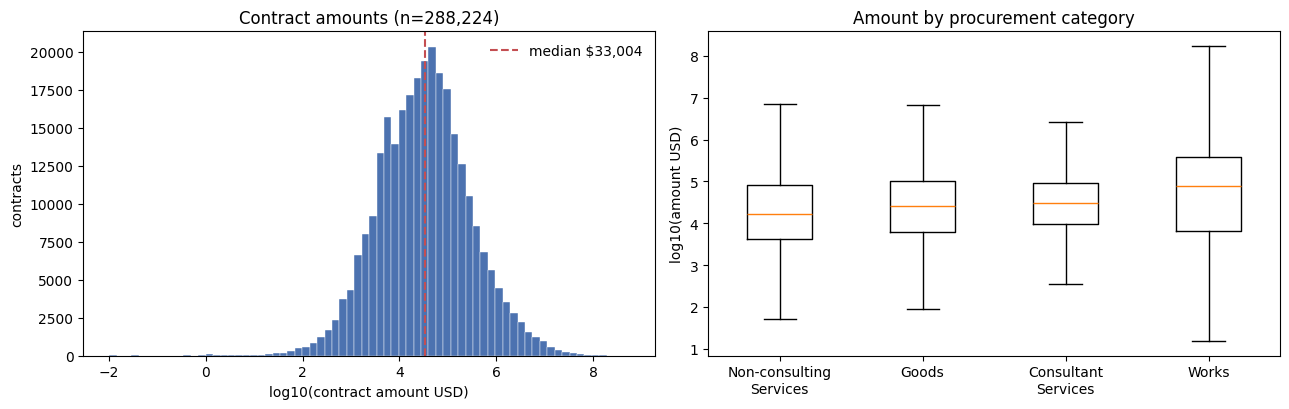

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
amt = features.loc[features.amount_usd > 0, "amount_usd"]
axes[0].hist(np.log10(amt), bins=70, color="#4C72B0", edgecolor="white", linewidth=.3)
axes[0].set(xlabel="log10(contract amount USD)", ylabel="contracts",
            title=f"Contract amounts (n={len(amt):,})")
axes[0].axvline(np.log10(amt.median()), color="#C44E52", ls="--",
                label=f"median ${amt.median():,.0f}")
axes[0].legend(frameon=False)

order = features.groupby("procurement_category")["amount_usd"].median().sort_values().index
axes[1].boxplot([np.log10(features.loc[features.procurement_category==c, "amount_usd"].dropna()
                          .pipe(lambda s: s[s>0])) for c in order],
                labels=[c.replace(" ", "\n") for c in order], showfliers=False)
axes[1].set(ylabel="log10(amount USD)", title="Amount by procurement category")
plt.tight_layout(); plt.show()

### 6.2 Procurement category mix and regional coverage

Coverage is broad but uneven: the two Africa regions hold 44% of contracts. The `Other` region
(295 rows: "World", "Multi-Regional") is what drives the thin-cell fallback in Section 4.1.

In [18]:
S.category_region_mix(features)

procurement_category,Consultant Services,Goods,Non-consulting Services,Works,Total
region,,,,,
East Asia and Pacific,13004,6867,2986,5434,28291
Eastern and Southern Africa,25773,25124,4378,11014,66289
Europe and Central Asia,12983,8425,2064,4721,28193
Latin America and Caribbean,20566,8069,7237,2720,38592
"Middle East, North Africa, Afghanistan, and Pakistan",6060,5425,949,2707,15141
Other,247,22,25,1,295
South Asia,6011,16306,1155,26767,50239
Western and Central Africa,25247,20291,4281,11378,61197
Total,109891,90529,23075,64742,288237


In [19]:
S.region_coverage(features)

,contracts,share_pct,total_usd_bn,median_usd,non_competitive_pct
region,,,,,
Eastern and Southern Africa,66289,23.00,31.33,"39,357.00",12.30
Western and Central Africa,61197,21.20,25.65,"52,653.00",13.80
South Asia,50239,17.40,16.27,"7,040.00",7.80
Latin America and Caribbean,38592,13.40,10.40,"13,814.00",16.80
East Asia and Pacific,28291,9.80,14.34,"48,283.00",9.80
Europe and Central Asia,28193,9.80,18.94,"51,900.00",14.10
"Middle East, North Africa, Afghanistan, and Pakistan",15141,5.30,13.16,"48,910.00",11.40
Other,295,0.10,0.01,"7,960.00",46.10


### 6.3 Fiscal-year coverage — the caveat the model split depends on

The intended split is FY2020–22 for training, FY2023 for validation, and **the most recent available
fiscal year** for the final test. Taken literally that last one is FY2027 — and FY2027 is a trap:

- **1,170 rows** against a ~41,000 norm, because the extract was frozen seven weeks into it.
- Prior-review share of **17.3%** vs. the ~7% baseline — large contracts clear prior review and get
  reported quickly; small post-review contracts trickle in over months.

Testing on FY2027 would measure **reporting lag, not model skill**, and would do so in a direction
that flatters the model — over-representing exactly the large, non-competitive contracts the risk
target is built from.

**Decision:** FY2027 is quarantined as an explicitly-labelled truncated holdout; FY2024–26 serve as
the test window. Taking "most recent available" literally here would produce a misleading
evaluation, so it is deliberately not taken literally.

In [20]:
S.fiscal_year_coverage(features)

,contracts,total_usd_bn,median_usd,prior_review_pct,vs_typical,completeness
fiscal_year,,,,,,
2020,35060,15.08,"32,350.00",8.10,0.86,complete
2021,44898,19.11,"23,359.00",6.60,1.10,complete
2022,40860,19.24,"29,900.00",6.20,1.00,complete
2023,43723,17.43,"31,152.00",5.90,1.07,complete
2024,45787,20.81,"35,016.00",6.70,1.12,complete
2025,45243,20.63,"37,679.00",6.80,1.11,complete
2026,31496,17.05,"44,459.00",9.90,0.77,partial - reporting lag
2027,1170,0.75,"67,763.00",17.30,0.03,TRUNCATED - extract frozen mid-year


### 6.4 Benchmark drift — the cost of freezing

Freezing medians on FY2020–22 buys reproducibility and removes look-ahead bias. It costs accuracy as
the portfolio moves. Quantified rather than asserted, so the refresh cadence can be an evidence-based
decision. Drift within roughly ±25% is tolerable for a *relative* risk benchmark; beyond that the
artefact should be re-fitted and its version bumped.

In [21]:
S.benchmark_drift(clean)

procurement_category,Consultant Services,Goods,Non-consulting Services,Works
fiscal_year,,,,
2020,-1.10,5.40,84.20,100.90
2021,-0.60,-0.50,-48.50,-41.20
2022,1.60,-5.60,97.80,-6.40
2023,22.00,-17.70,148.20,10.60
2024,36.10,10.80,170.50,-19.90
2025,42.60,35.20,85.70,-2.20
2026,51.70,89.10,239.30,19.60
2027,90.50,197.20,555.90,469.30


### 6.5 Prior-review slice

The population modelled is all records, but the business framing concerns prior review. This slice
confirms the two groups are genuinely different — prior-review contracts have a median ~25x higher
and a 95th percentile ~23x higher —
which is why `review_type` is retained as a feature rather than used as a filter.

In [22]:
pd.DataFrame({
    "contracts": features.groupby("review_type").size(),
    "median_usd": features.groupby("review_type").amount_usd.median().round(0),
    "p95_usd": features.groupby("review_type").amount_usd.quantile(.95).round(0),
    "non_competitive_pct": (features.groupby("review_type").is_competitive_method
                            .apply(lambda s: (s==False).mean())*100).round(1),
})

,contracts,median_usd,p95_usd,non_competitive_pct
review_type,,,,
Post,267801,"28,022.00","692,623.00",12.20
Prior,20394,"704,184.00","16,007,498.00",13.90


## 7. `validate_and_enrich` — the per-record contract

The entry point every downstream stage builds on.

```python
EnrichedRecord(
    ok: bool,                       # False -> classified NOT_ELIGIBLE
    features: dict | None,          # None when a required field failed
    data_quality_flags: list[str],  # audit-record reason codes
    normalized: dict,               # cleaned passthrough for the audit record
)
```

Guarantees:

- **Never imputes a required field.** A missing amount fails the record; it does not become a median.
- **Degrades precisely.** An optional-field problem nulls exactly one feature and flags it.
- **Pure.** No clock, no globals, no file reads — only the record and the frozen `ReferenceStats`.
  This is what makes the audit record reproducible.
- **One code path.** The batch table and the per-record call are verified to agree on all 15
  features (test: `test_scalar_and_batch_feature_paths_agree`). Building this check is what surfaced
  two real defects — a `NaN`-vs-`None` gap that silently substituted the global median for a missing
  global practice, and the double-space method bug.

In [23]:
import json
def show(title, rec):
    res = validate_and_enrich(rec, stats)
    print(f"=== {title} ===")
    print(f"ok={res.ok}  flags={res.data_quality_flags}")
    if res.features:
        print(json.dumps({k: (round(v,4) if isinstance(v,float) else v)
                          for k,v in res.features.items()}, indent=2, default=str))
    print()

routine = features[(features.method_class=="COMPETITIVE") &
                   (features.amount_vs_category_region_median.between(0.8,1.2)) &
                   (features.supplier_prior_contract_count>3)].iloc[0].to_dict()
large_direct = features[(features.method_class=="NON_COMPETITIVE") &
                        (features.amount_vs_category_region_median>50)].iloc[0].to_dict()
broken = features[features.amount_usd==0].iloc[0].to_dict()

show("A. Routine: competitive, at benchmark, established supplier", routine)
show("B. Elevated: non-competitive, far above benchmark", large_direct)
show("C. Fails validation: zero amount + missing supplier", broken)

=== A. Routine: competitive, at benchmark, established supplier ===
ok=True  flags=['MULTI_PRACTICE_PROJECT']
{
  "amount_usd": 36023.54,
  "log_amount": 4.5566,
  "amount_vs_category_region_median": 0.8182,
  "amount_vs_practice_median": 2.3088,
  "amount_percentile_in_category_region": 0.4423,
  "benchmark_support_n": 7409,
  "supplier_is_domestic": true,
  "is_first_contract_in_project": false,
  "project_contract_sequence": 20,
  "supplier_prior_contract_count": 5,
  "supplier_is_known": true,
  "days_into_fiscal_year": 41,
  "fy_quarter": 1,
  "is_competitive_method": true,
  "consortium_size": 1
}

=== B. Elevated: non-competitive, far above benchmark ===
ok=True  flags=['GLOBAL_PRACTICE_MISSING']
{
  "amount_usd": 5000000.0,
  "log_amount": 6.699,
  "amount_vs_category_region_median": 268.1281,
  "amount_vs_practice_median": null,
  "amount_percentile_in_category_region": 0.9871,
  "benchmark_support_n": 1555,
  "supplier_is_domestic": false,
  "is_first_contract_in_project": fa

Record **C** is the one that matters most. Every required field except the amount and supplier is
present and perfectly usable, and it would be trivially easy to fill the amount with a category
median and produce a confident-looking risk score. The function refuses, returns `features=None`,
and hands the rule engine two reason codes. **An unscoreable record is a finding, not a gap to be
patched.**

## 8. Assumptions, limitations, and what the next stage inherits

### Assumptions
1. **Amounts are comparable across time without deflation** (Section: Scope). Drift measured in 6.4.
2. **First-listed global practice is primary** — 48.2% of records list several and the field carries
   no ordering guarantee. Exploding to one row per practice would break the one-row-per-award grain
   the pipeline depends on.
3. **Normalised supplier name is the entity key**, not `Supplier ID` (Section 2.2).
4. **`Individual Consultant Selection` is competitive** (≥3 CVs compared under WB rules) even though
   its supplier field is a placeholder. The two facts are recorded independently so a rule can act
   on either.
5. **Benchmarks frozen on FY2020–22** and treated as a versioned artefact.

### Limitations, stated plainly
- **Publication lag is invisible to the pipeline.** History features count what was *signed* before a
  record, but a contract signed earlier may have been *published* later. Point-in-time correctness is
  therefore an upper bound on true information availability. Correcting for it would need a
  publication-date column the extract does not provide.
- **22% of records have no usable supplier history**, and they are not a random 22% — they are
  entirely individual-consultant awards. Any feature importance the model assigns to supplier
  history is conditioned on a non-random subpopulation.
- **No contract outcome data exists here.** There is no realised fraud, dispute or cancellation
  label anywhere in the extract. The risk target must therefore be *defined* rather than observed,
  which makes it partly circular — a limitation the modelling stage has to confront directly rather
  than paper over.
- **`Other` region (295 rows)** is a residual bucket, not a place. Its benchmarks fall back to the
  category level.

### Handed downstream
- `features` — 288,237 rows, 15 model-ready features plus cleaned fields.
- `stats` — the frozen `ReferenceStats` artefact (`v1.0`, benchmarks FY2020–22).
- `validate_and_enrich` — the per-record entry point.
- The `DataQualityFlag` vocabulary — **FATAL flags are the `NOT_ELIGIBLE` rules**, already computed
  and reconciled (13 records).
- Two findings that constrain rule design: the fiscal-year-window rule cannot fire (Section 2.5),
  and non-competitive amount thresholds must be set against *contract-grain* benchmarks
  (Section 2.3).

In [24]:
OUT = Path.cwd().parent / "data"
features.to_parquet(OUT / "contracts_features.parquet", index=False)
audit.to_parquet(OUT / "quality_audit.parquet")
register.to_csv(Path.cwd().parent / "reports" / "data_quality_register.csv", index=False)
print(f"features : {features.shape}")
print(f"scoreable: {int(audit.ok.sum()):,} / {len(audit):,}")
print("artefacts written to data/ and reports/")

features : (288237, 49)
scoreable: 288,224 / 288,237
artefacts written to data/ and reports/
